# Models and tests


**Models**

We used the following model:
- flan-t5 (large and base)
- Phi-3-mini-4k-instruct

We tested them and tried to improve their performances through:
- RAG
- Fine-tuning
- prompting a LLM

**Testing problem**

Certainly one problem with generative LLMs is testing the correctness of the answers given, which may appear plausible because of the hallucination phenomenon. There are basically two ways to test the thruthfulness of the answers:

1. manually evaluate that the output provided is true
2. use a set of multiple-choice questions as testing (declined in different ways)

One could provide the model with only the questions, without the answer options, but in this way all those answers that, although containing true information, do not include the option designated as correct would be considered as incorrect.

In [ ]:
# Sentence transformer
semb_model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')

# Encoder
xenc_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# Model
model_source="google/flan-t5-large"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = T5Tokenizer.from_pretrained(model_source)
model = T5ForConditionalGeneration.from_pretrained(model_source, device_map="cuda", torch_dtype=torch.bfloat16)

## RAG

### setup


**Settings**

Here we define a few settings that will be useful during the testing phase.

In [ ]:
# Load embeddings and path
load_embeddings=False
embeddings_cache_path = './qa_flashcards_embeddings_cache.pkl'
# Load Indexes and path
load_indexes=False
index_path = './qa_dataset_hnswlib.index'
# Number of passages to select
n_passages=1

# Before-passage prompt
#the prompt to ask the model has the following structure: ...text... {cosine similarity passage} ...text... {question}
#modifing the text values might yield different results.
before_passage='Given the following reference, answer the question. \nReference:'
before_question='\n Question:'

**Dataset Setup**

In [6]:
combined_dataset={
    "original": copy.deepcopy(wikidoc),
    "wikidoc" : copy.deepcopy(original),
    "medqa"   : copy.deepcopy(medqa_cleaned)
}

og_q, og_a  =zip(*[(item.pop('input'), item.pop('output')) for item in copy.deepcopy(original)])
wikidoc_q, wikidoc_a = zip(*[(item.pop('input'), item.pop('output')) for item in copy.deepcopy(wikidoc)])
medqa_q, medqa_a  =zip(*[(item.pop('input'), item.pop('output')) for item in copy.deepcopy(medqa_cleaned)])

combined_questions={
    "original": og_q,
    "wikidoc" : wikidoc_q,
    "medqa"   : medqa_q
}

combined_answers={
    "original": og_a,
    "wikidoc" : wikidoc_a,
    "medqa"   : medqa_a
}

merged_questions={
    "questions": og_q + wikidoc_q + medqa_q
}
merged_answers={
    "answers": og_a + wikidoc_a + medqa_a
}

# define the structure for the passage retrieval. Will be used later during the pipeline
passages={
    "original": 'placeholder',
    "wikidoc" : 'placeholder',
    "medqa"   : 'placeholder'
}
# to avoid overwriting the tests that we might use later for other purposes, we make deep copies of all the tests
USMLE_solutions=[]
data1=copy.deepcopy(step1)
data2=copy.deepcopy(step2)
data3=copy.deepcopy(step3)

sol1=copy.deepcopy(step1_sol)
sol2=copy.deepcopy(step2_sol)
sol3=copy.deepcopy(step3_sol)

USMLE_dataset=data1+data2+data3

USMLE_solutions.append(sol1)
USMLE_solutions.append(sol2)
USMLE_solutions.append(sol3)

# Now we do a bit of pre-processing on the test set
prepared_questions=[]
print(USMLE_dataset[0])

for question_data in USMLE_dataset:
    question_text = question_data["question"]
    options_text = ", ".join([f"{key}: {value}" for key, value in question_data["options"].items()])
    combined_text = f"{question_text} {options_text}"
    prepared_questions.append(combined_text)

scoring  = [value for d in USMLE_solutions for value in d.values()]

{'no': 1, 'question': 'Serum LDL-cholesterol concentrations are measured in blood samples collected from 25 healthy volunteers. The data follow a normal distribution. The mean and standard deviation for this group are 130 mg/dL and 25 mg/dL, respectively. The standard error of the mean is 5.0. With a 95% confidence level, the true mean for the population from which this sample was drawn falls within which of the following ranges (in mg/dL)?', 'options': {'A': '105-155', 'B': '120-140', 'C': '125-135', 'D': '128-132', 'E': '129-131'}}


**Embeddings and Indexes**

We perform similarity for retrieval only on the questions, since we want to find in our dataset the closest question to the one prompted to the model.

For this reason we only embed and index the questions from the available datasets

In [ ]:
def embed(dataset_list, path=embeddings_cache_path, save=False):
  # Load cache if available
  if os.path.exists(path) and load_embeddings:
      with open(path, 'rb') as f:
          corpus_embeddings = pickle.load(f)
  # Else compute embeddings
  else:
      corpus_embeddings = semb_model.encode(dataset_list, convert_to_tensor=True, show_progress_bar=True)
      return corpus_embeddings

def indexing(corpus_embeddings, path=index_path, save=False):
  # Create empthy index
  index = hnswlib.Index(space='cosine', dim=384)

  if os.path.exists(path) and load_indexes:
      index.load_index(path)
  else:
      index.init_index(max_elements=corpus_embeddings.size(0), ef_construction=400, M=64)
      index.add_items(corpus_embeddings.cpu(), list(range(len(corpus_embeddings))))
      return index

In [ ]:
#Since we will perform retrieval only on the questions, then we must embed and index only that
indexed_questions={
    "original": indexing(embed(combined_questions['original'])),
    "wikidoc" : indexing(embed(combined_questions['wikidoc'])),
    "medqa"   : indexing(embed(combined_questions['medqa']))
}

merged_index={
    "questions":indexing(embed(merged_questions['questions']))
}

**Utils**

We define some functions that will be used later.

In [ ]:
#Given a dataset and a question, find the question position in the dataset
def find_position(dataset, question):
    for i, obj in enumerate(dataset):
        if obj == question:
            return i
    return -1

#Given a question, find the most similar in the given dataset
def find_similar(question, embedded_question, indexed_dataset, dataset, similarity_model=semb_model, re_ranking_model=xenc_model):


    corpus_ids, distances = indexed_dataset.knn_query(embedded_question.cpu(), k=64)
    xenc_model_inputs = [(question, dataset[idx]) for idx in corpus_ids[0]]
    cross_scores = re_ranking_model.predict(xenc_model_inputs)
    passage_indices = np.argsort(-cross_scores)[0]  #pick the best one
    passage_idx=passage_indices
    passage=dataset[corpus_ids[0][passage_idx]]

    return passage #most similar question


#retrieval main function. Find the most similar passage from up to all the datasets. Also has option to only consider the best among all the datasets available
def prepare_passage(question, embedded_question, separate_similarity=True,indexed_dataset=indexed_questions, dataset=combined_questions, use_all_datasets=True, similarity_model=semb_model, re_ranking_model=xenc_model):
    if(separate_similarity):
      passages['original']=find_similar(question, embedded_question, indexed_questions['original'], combined_questions['original'], similarity_model, re_ranking_model)
      if(use_all_datasets):
        passages['medqa']=find_similar(question, embedded_question, indexed_questions['medqa'], combined_questions['medqa'], similarity_model, re_ranking_model )
        passages['wikidoc']=find_similar(question, embedded_question, indexed_questions['wikidoc'], combined_questions['wikidoc'], similarity_model, re_ranking_model)

      pos_ans=find_position(combined_questions['original'], passages['original'])
      passage=combined_answers['original'][pos_ans]
      if(use_all_datasets):
        pos_ans=find_position(combined_questions['medqa'], passages['medqa'])
        passage+='\n' + combined_answers['medqa'][pos_ans]
        pos_ans=find_position(combined_questions['wikidoc'], passages['wikidoc'])
        passage+='\n' + combined_answers['wikidoc'][pos_ans]
    else:
      passages['original']=find_similar(question, embedded_question, merged_index['questions'], merged_questions['questions'], similarity_model, re_ranking_model)
      pos_ans=find_position(merged_questions['questions'], passages['original'])
      passage=merged_answers['answers'][pos_ans]
    return passage

#given a row of a dataframe, checks if the symptom is present
def check_symptom_in_row(symptom, row):
    # Get the symptoms from the row
    symptom = symptom.lower()
    symptoms = row['Symptom'].lower()
    # Check if the symptom is in the symptoms
    return symptom in symptoms

In [ ]:
#given 2 lists, find the accuracy, where points are "given" only with an exact match
def find_accuracy(generated, ground_truth):
  matches = sum(1 for x, y in zip(ground_truth, generated) if x == y)
  accuracy = matches / len(ground_truth) * 100

  # Print the resulting accuracy
  return accuracy

**Pipeline**

Here we define the pipeline used for prompting the model.

inputs:
- question: question asked by the user
- Retireval: if True, perform retireval, il False, prompt the model directly with the question
- return_verbose: For visualization purposes, we allowed the pipeline to return the question asked with the retireved passage and the generated output. Normally use False if only the generated text is desired
- separate_similarity: When using multiple datasets, there are a few options we can make while prompting the model. If False, the best similarity among the three datasets is used, If false, all datasets will commit one passage.
- similarity_model: model used for similarity computation
- re_ranking_model: cross encoder used
- generative_model: model used for generation
- device: gpu/cpu

In [ ]:
def qa_pipeline(
    question,
    q_index=indexed_questions,   #indexed questions
    retrieval=True,
    return_verbose=False,        #Normally, only generated text is returned. if True, return structure of input, retrived passage and generated output
    use_all_datasets=True,
    separate_similarity=True,    #if True, find the most similar passage for each dataset.
    similarity_model=semb_model, #sentenceTransformer
    re_ranking_model=xenc_model, #encoder
    generative_model=model,      #model (google FLAN-T5)
    device=device
):
    if not question.endswith('?'):
        question = question + '?'
    if(retrieval):
      # Embed question
      embedded_question = similarity_model.encode(question, convert_to_tensor=True)
      #find most similar with original dataset questions
      passage=prepare_passage(question, embedded_question, use_all_datasets=use_all_datasets, separate_similarity=separate_similarity)
      input_text = f"{before_passage} {passage} {before_question} {question}"
    else:
      input_text=f"Please answer this question: {question}"

    input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)
    # Generate output
    output_ids = generative_model.generate(input_ids, max_new_tokens=64, early_stopping=False,do_sample=True,  temperature=0.7)
    # Decode output
    output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    if(return_verbose):
      if(retrieval):
        return f'\nQuestion:\n{question}\nExtracted passage(s):\n{passage}\ngenerated response:\n{output_text}'
      else:
        return f'\nQuestion:\n{question}\ngenerated response:\n{output_text}'
    # Return result
    else:
      return output_text


In [ ]:
index='placeholder' #reference is declared later
def qa_pipeline_book(
    question,
    similarity_model=semb_model, #sentenceTransformer
    embeddings_index=index,      #indexed dataset
    re_ranking_model=xenc_model, #encoder
    generative_model=model,      #model (google FLAN-T5)
    device=device
):
    if not question.endswith('?'):
        question = question + '?'
    # Embed question
    question_embedding = semb_model.encode(question, convert_to_tensor=True)
    # Search documents similar to question in index
    corpus_ids, distances = index.knn_query(question_embedding.cpu(), k=64)
    # Re-rank results
    xenc_model_inputs = [(question, dataset_list[idx]) for idx in corpus_ids[0]]
    cross_scores = xenc_model.predict(xenc_model_inputs)
    # Get best matching passage
    passage_indices = np.argsort(-cross_scores)[:10]  #AUMENTA SE VUOI POI SELEZIONARE PIù DI 10 PASSAGGI

    # Select passages using the retrieved indices
    passage_idx=passage_indices[:8] #CAMBIA QUA SE VUOI AUMENTARE IL NUMERO DI PASSAGGI DA INCLUDERE NEL PROMPT AL MODELLO
    a=''
    for passage_indx in passage_idx:
        passage = f'{a} {dataset_list[corpus_ids[0][passage_indx]]}'
        a=passage
    # Encode input
    #modificando il prompt qua sotto è possibile ottenere risultati diversi anche con la stessa domanda e passaggio
    #ad esempio usando "in a verbose way" subito dopo "related question"
    input_text = f"Given the following passage, answer the related question selecting the right index.\n\nPassage:\n\n{passage}\n\nQ: {question}"
    input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)
    # Generate output
    output_ids = model.generate(input_ids, max_new_tokens=64)
    # Decode output
    output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # Return result
    return output_text

### RAG with only our dataset

**Testing without retrieval**

Before using our datasets, let's first set a baseline by running the pipeline without performing retrieval

In [ ]:
# test the dataset
results=[]
for question in prepared_questions:
    results.append(qa_pipeline(question, retrieval=False))

#find accuracy
pprint.pprint(find_accuracy(scoring, results))

Token indices sequence length is longer than the specified maximum sequence length for this model (554 > 512). Running this sequence through the model will result in indexing errors


29.78142076502732


**Testing with retrieval**

We begin by employing the RAG, then, after indexing the data we have, we use the index to retrieve the passage whose question is as close as possible to the one provided as input. Hopefully, the passage will contain useful information for the model to formulate a correct answer

Now we test using only our original dataset, to see if the retrieval improves the results.


In [ ]:
results=[]
for question in prepared_questions:
    results.append(qa_pipeline(question, retrieval=True,use_all_datasets=False))

pprint.pprint(find_accuracy(scoring, results))

30.05464480874317


**Considerations**

The results are not great, this could be due to two factors:
1. the context retrival is ineffective, resituating passages that are not very relevant to the question
2. in the database from which the context is extracted, not enough information is present, so the model is left with no choice but to invent an answer out of thin air

###RAG with multiple datasets
While the score did improve, the improvement is nearly negligible. Our first idea is that the dataset provided is too small for the task we set out to beat. Here we will use retrieval with all the datasets.

**Taking best passage of each dataset**

In [ ]:
results=[]
for question in prepared_questions:
    results.append(qa_pipeline(question, retrieval=True,use_all_datasets=True))

pprint.pprint(find_accuracy(scoring, results))

Token indices sequence length is longer than the specified maximum sequence length for this model (658 > 512). Running this sequence through the model will result in indexing errors


30.327868852459016


**Taking the best passage among all datasets**

Maybe giving the model 3 different passages might be too much. Here we will only select the best passage from all the datasets.

In [ ]:
#Note, while use_all_datasets is set to false, the pipeline is actually using another dataset, which is all the other 3 combined, due to the separate_similarity clause
results=[]
for question in prepared_questions:
    results.append(qa_pipeline(question, retrieval=True,use_all_datasets=False, separate_similarity=False))

pprint.pprint(find_accuracy(scoring, results))

27.322404371584703


### RAG with some books

Let's try to use a more various and bigger dataset, some books!!!

#### Books analysis


Lets's start with one of them

In [ ]:
# Load the book
path_books = 'docs/books'
with open(f'{path_books}/Obstentrics_Williams.txt') as f:
    book = f.read()

Inspect the book

In [ ]:
# Split the book into lines
lines = book.splitlines()

# Calculate the total number of lines
total_lines = len(lines)
print("Number of lines:", total_lines)

# Calculate the sum of the lengths of all lines
total_length = sum(len(line) for line in lines)

# Calculate the average length of the lines
average_length = total_length / total_lines if total_lines > 0 else 0

# Print the average length
print("Average length of the lines:", average_length)

Number of lines: 43605
Average length of the lines: 149.97722738218096


So many lines (paragraphs)! But are all of them useful?

<function matplotlib.pyplot.show(close=None, block=None)>

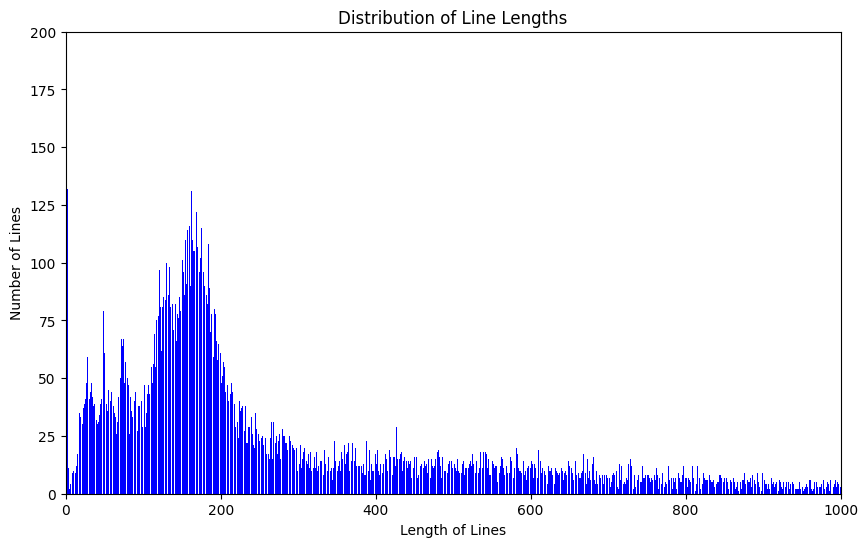

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Calculate the length of each line
lengths = [len(line) for line in lines]

# Count the number of occurrences of each length
length_counts = Counter(lengths)

# Get the lengths and their corresponding counts
lengths = list(length_counts.keys())
counts = list(length_counts.values())

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(lengths, counts, color='blue')

# Add labels and title
plt.xlabel('Length of Lines')
plt.ylabel('Number of Lines')
plt.title('Distribution of Line Lengths')

# Set axis ranges
plt.xlim(0, 1000)
plt.ylim(0, 200)

# Show the plot
plt.show

In [ ]:
for line in lines:
  if len(line)>100:
    print(line)
    break

In the olowingpages I have attempted to set orth, as brily as seemed to be consistent with thoroughness, the scientic basis or and the practical application of the obstetrical art. At the same time, I have endeavored to present the more practical aspects of obstetrics in such a manner as to be of direct service to the obstetrician at the bedside.


From this line and from manual inspection of the books, it is apparent that there are often paragraphs that do not bring in additional notions; these are often short being of various kinds, short introductions, references, quotations. Quite naively we choose to remove paragraphs that are less than a given treshold in length, to reduce the number of documents in the index.

In [ ]:
counts_lines = []
# Filter out lines that have fewer than 400 characters
filtered_lines = [line for line in lines if len(line) >= average_length]

# Calculate the total number of filtered lines
total_lines = len(filtered_lines)
print("Number of lines:", total_lines)
counts_lines.append(total_lines)

Number of lines: 14446


Now we repeat the same passages for other books

In [ ]:
other_books = ['Obstentrics_Williams.txt', 'Anatomy_Gray.txt', 'Cell_Biology_Alberts.txt', 'Histology_Ross.txt', 'InternalMed_Harrison.txt', 'Neurology_Adams.txt', 'Pathoma_Husain.txt', 'Pediatrics_Nelson.txt', 'Pharmacology_Katzung.txt', 'Psichiatry_DSM-5.txt', 'Biochemistry_Lippincott.txt', 'Gynecology_Novak.txt', 'Immunology_Janeway.txt', 'Pathology_Robbins.txt', 'Physiology_Levy.txt']

Obstentrics_Williams.txt
Number of lines: 43605
Average length of the lines: 149.97722738218096


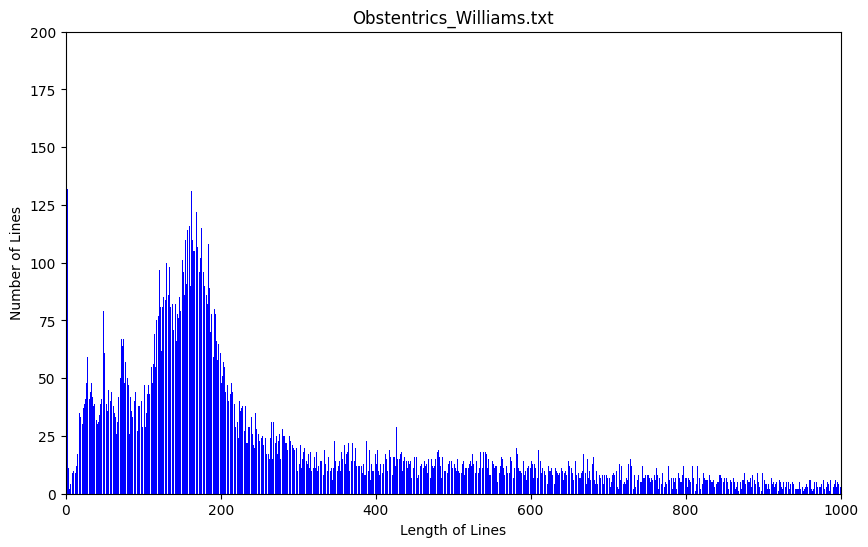

Anatomy_Gray.txt
Number of lines: 19943
Average length of the lines: 113.38389409817981


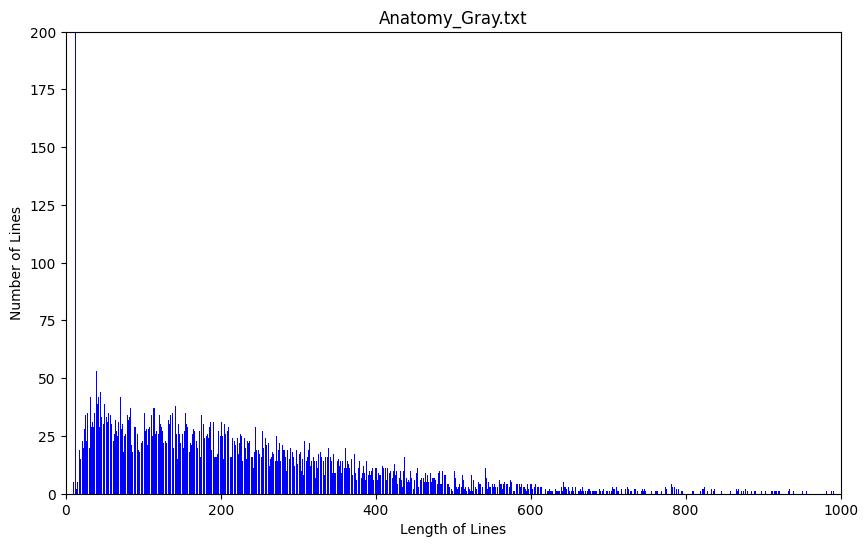

Cell_Biology_Alberts.txt
Number of lines: 21253
Average length of the lines: 228.0621559309274


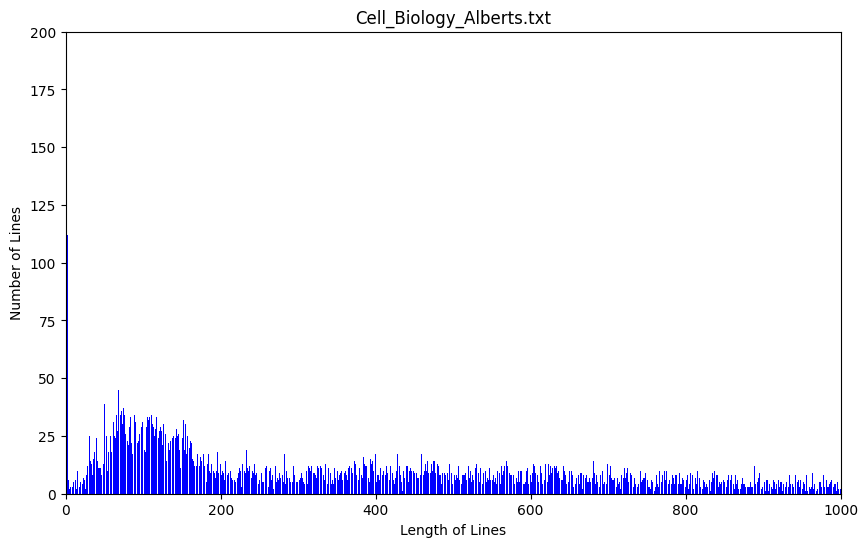

Histology_Ross.txt
Number of lines: 13379
Average length of the lines: 226.74654308991703


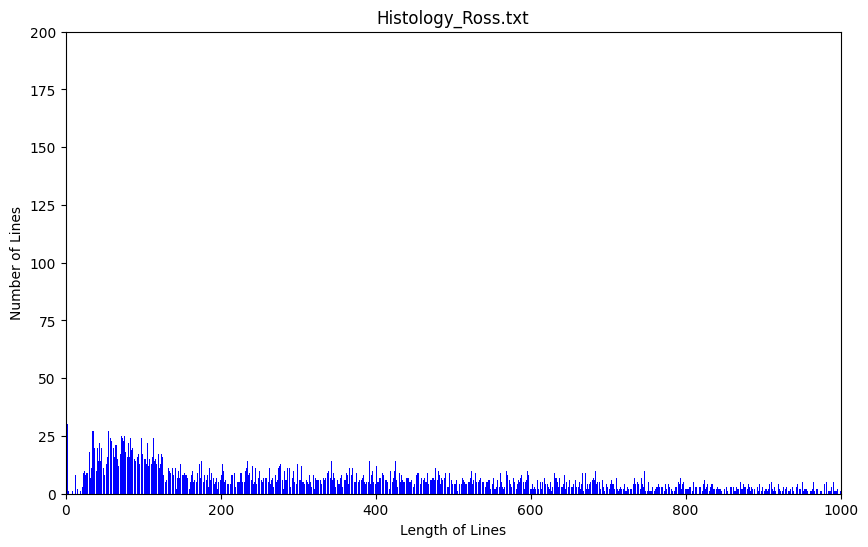

InternalMed_Harrison.txt
Number of lines: 79041
Average length of the lines: 281.294758416518


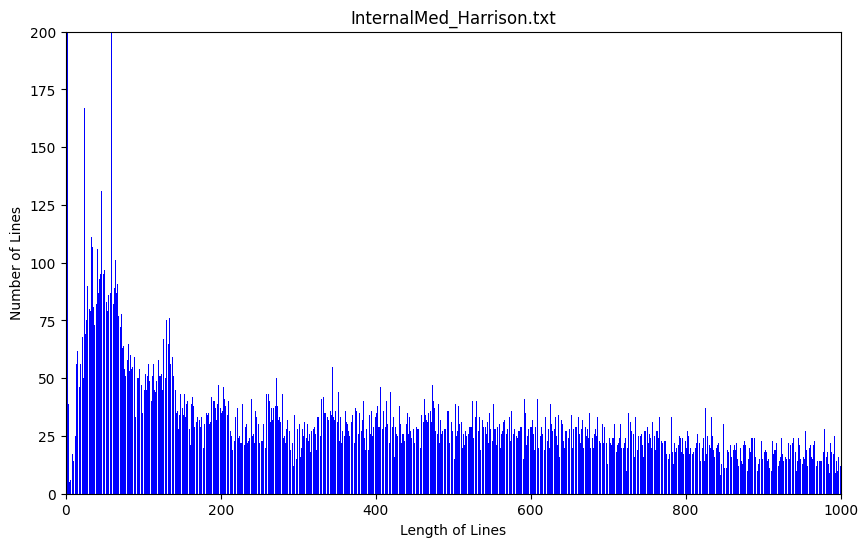

Neurology_Adams.txt
Number of lines: 33607
Average length of the lines: 247.93587645431012


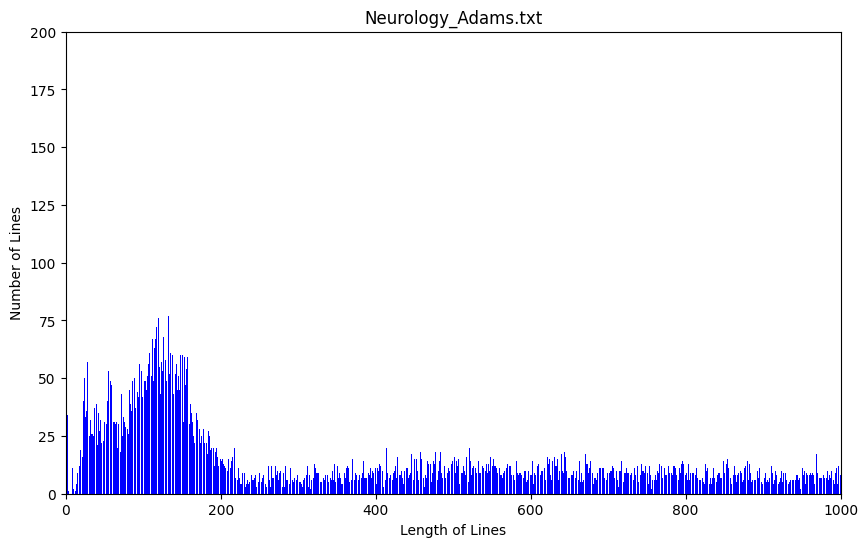

Pathoma_Husain.txt
Number of lines: 10611
Average length of the lines: 36.68117990764301


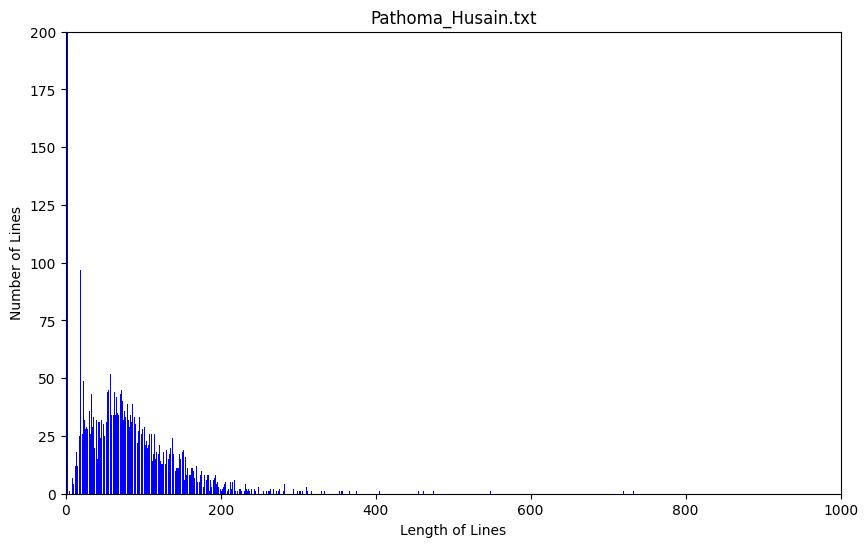

Pediatrics_Nelson.txt
Number of lines: 16067
Average length of the lines: 185.86114395966888


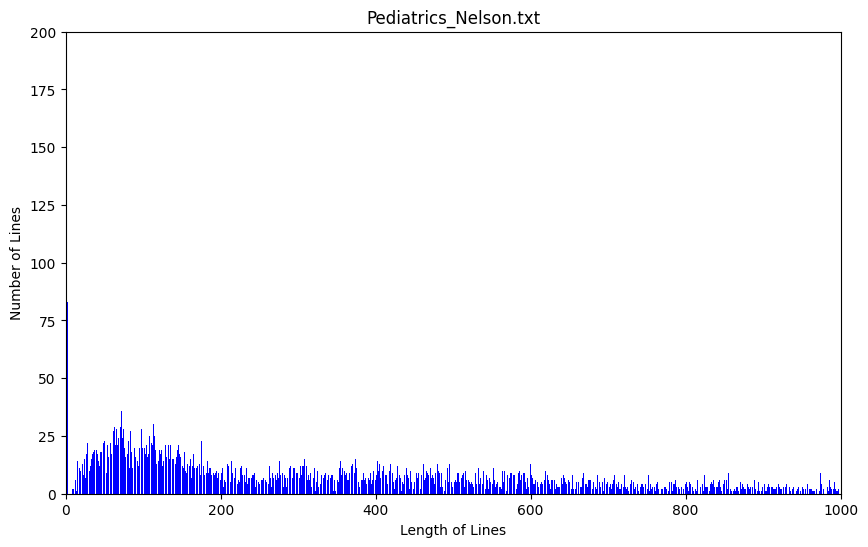

Pharmacology_Katzung.txt
Number of lines: 25737
Average length of the lines: 198.0235070132494


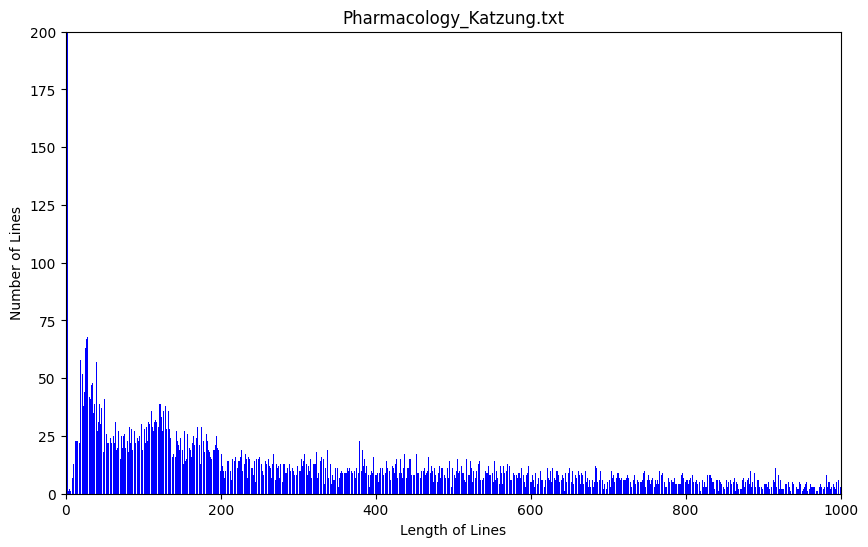

Psichiatry_DSM-5.txt
Number of lines: 25721
Average length of the lines: 111.49014424011509


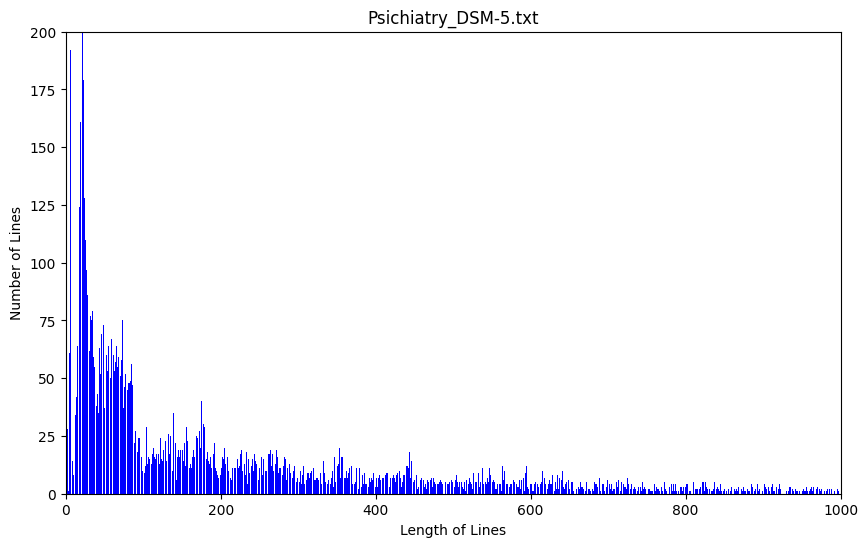

Biochemistry_Lippincott.txt
Number of lines: 8589
Average length of the lines: 156.13319361974618


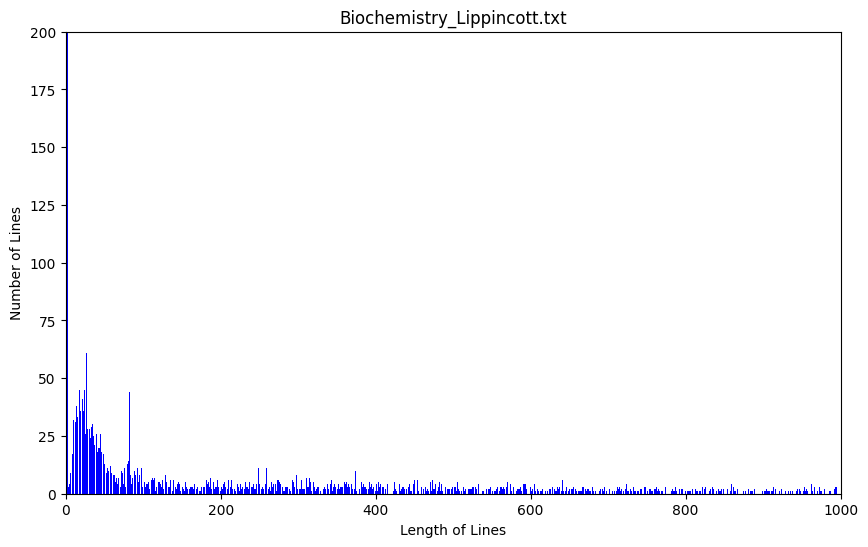

Gynecology_Novak.txt
Number of lines: 50035
Average length of the lines: 111.31639852103528


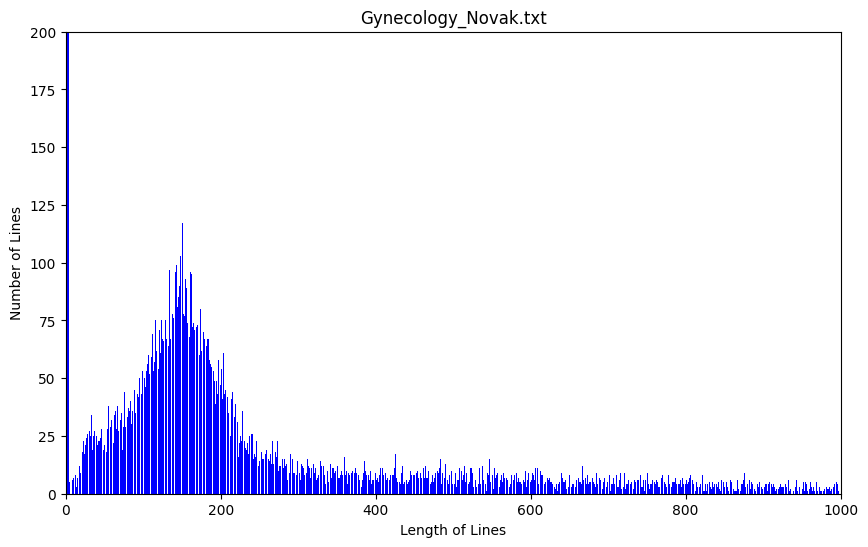

Immunology_Janeway.txt
Number of lines: 16485
Average length of the lines: 200.0975432211101


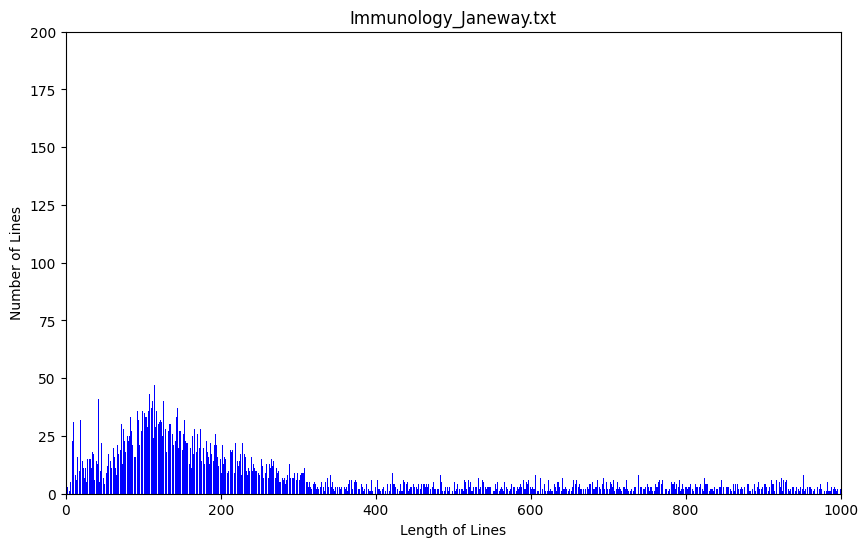

Pathology_Robbins.txt
Number of lines: 22795
Average length of the lines: 165.04075455143672


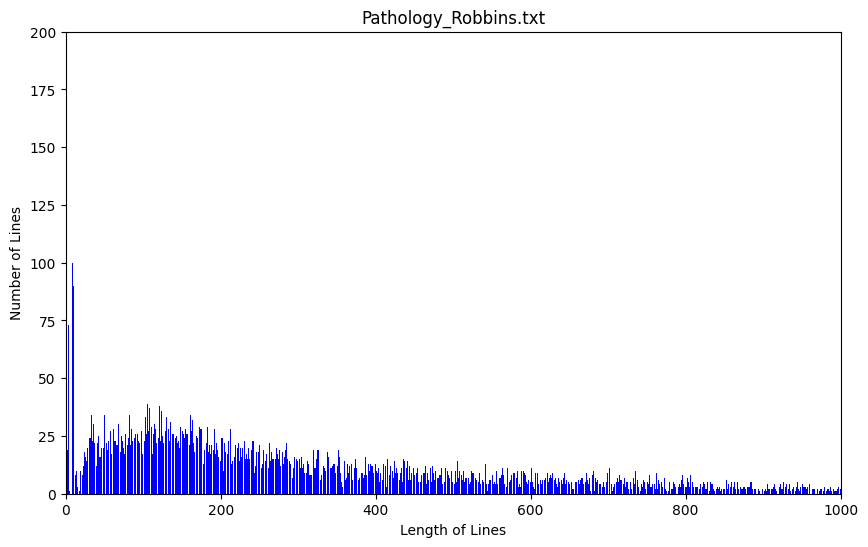

Physiology_Levy.txt
Number of lines: 17717
Average length of the lines: 171.10797539086752


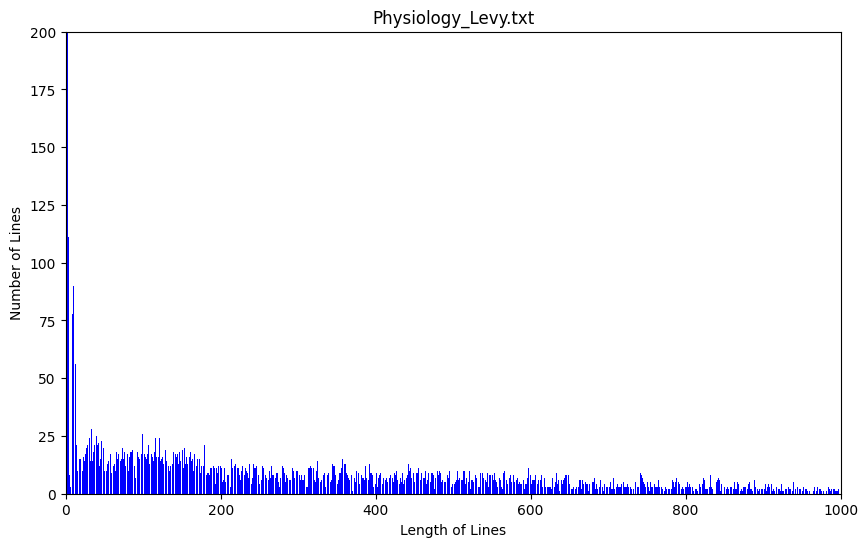

In [ ]:
lines_all_books = []
thresholds = []

for book_i in other_books:
  with open(f'{path_books}/{book_i}') as f:
    book = f.read()
    # Split the book into lines
  lines = book.splitlines()

  print(book_i)

  # Calculate the total number of lines
  total_lines = len(lines)
  print("Number of lines:", total_lines)

  # Calculate the sum of the lengths of all lines
  total_length = sum(len(line) for line in lines)

  # Calculate the average length of the lines
  average_length = total_length / total_lines if total_lines > 0 else 0

  # Print the average length
  print("Average length of the lines:", average_length)

    # Calculate the length of each line
  lengths = [len(line) for line in lines]

  # Count the number of occurrences of each length
  length_counts = Counter(lengths)

  # Get the lengths and their corresponding counts
  lengths = list(length_counts.keys())
  counts = list(length_counts.values())

  # Plot the data
  plt.figure(figsize=(10, 6))
  plt.bar(lengths, counts, color='blue')

  # Add labels and title
  plt.xlabel('Length of Lines')
  plt.ylabel('Number of Lines')
  plt.title(book_i)

  # Set axis ranges
  plt.xlim(0, 1000)
  plt.ylim(0, 200)


  # Show the plot
  plt.show()

  #Add the lines
  lines_all_books.append(lines)
  thresholds.append(average_length)

Now we remove all the paragraphs that have less than the chosen treshold

In [ ]:
index = 0
dataset_list = []
book_paragraphs = []
counts_lines = []

for lines in lines_all_books:
  # Filter out lines that have fewer than thre
  filtered_lines = [line for line in lines if len(line) >= thresholds[index]/2]

  for line in filtered_lines:
    dataset_list.append(line)

  index = index+1

  # Calculate the total number of filtered lines
  total_lines = len(filtered_lines)
  #print("Number of lines:", total_lines)
  counts_lines.append(total_lines)


  book_paragraphs.append(filtered_lines)

We plot the number of pharahraphs per book

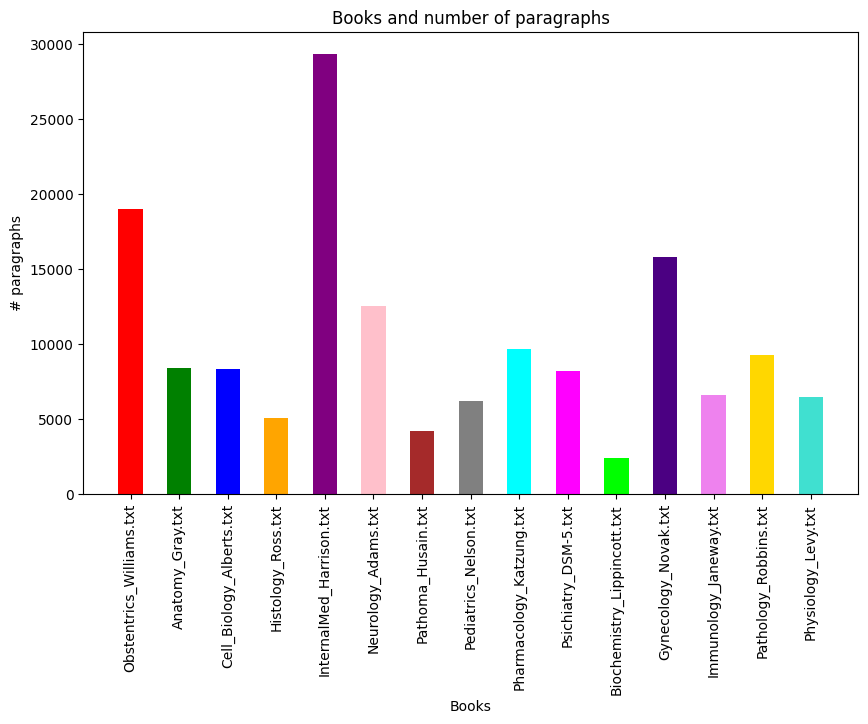

In [ ]:
import matplotlib.pyplot as plt

all_books = other_books.copy()


# Create a bar chart with separated bars
bar_width = 0.5  # Width of the bars

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# List of colors for each bar
colors = [
    'red', 'green', 'blue', 'orange', 'purple',
    'pink', 'brown', 'gray', 'cyan', 'magenta',
    'lime', 'indigo', 'violet', 'gold', 'turquoise'
]


# Create bars with specified width
bars = ax.bar(all_books, counts_lines, width=bar_width, color=colors)

# Rotate x-axis labels to be vertical
plt.xticks(rotation=90)

# Add title and labels
ax.set_title('Books and number of paragraphs')
ax.set_xlabel('Books')
ax.set_ylabel('# paragraphs')

# Display the plot
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


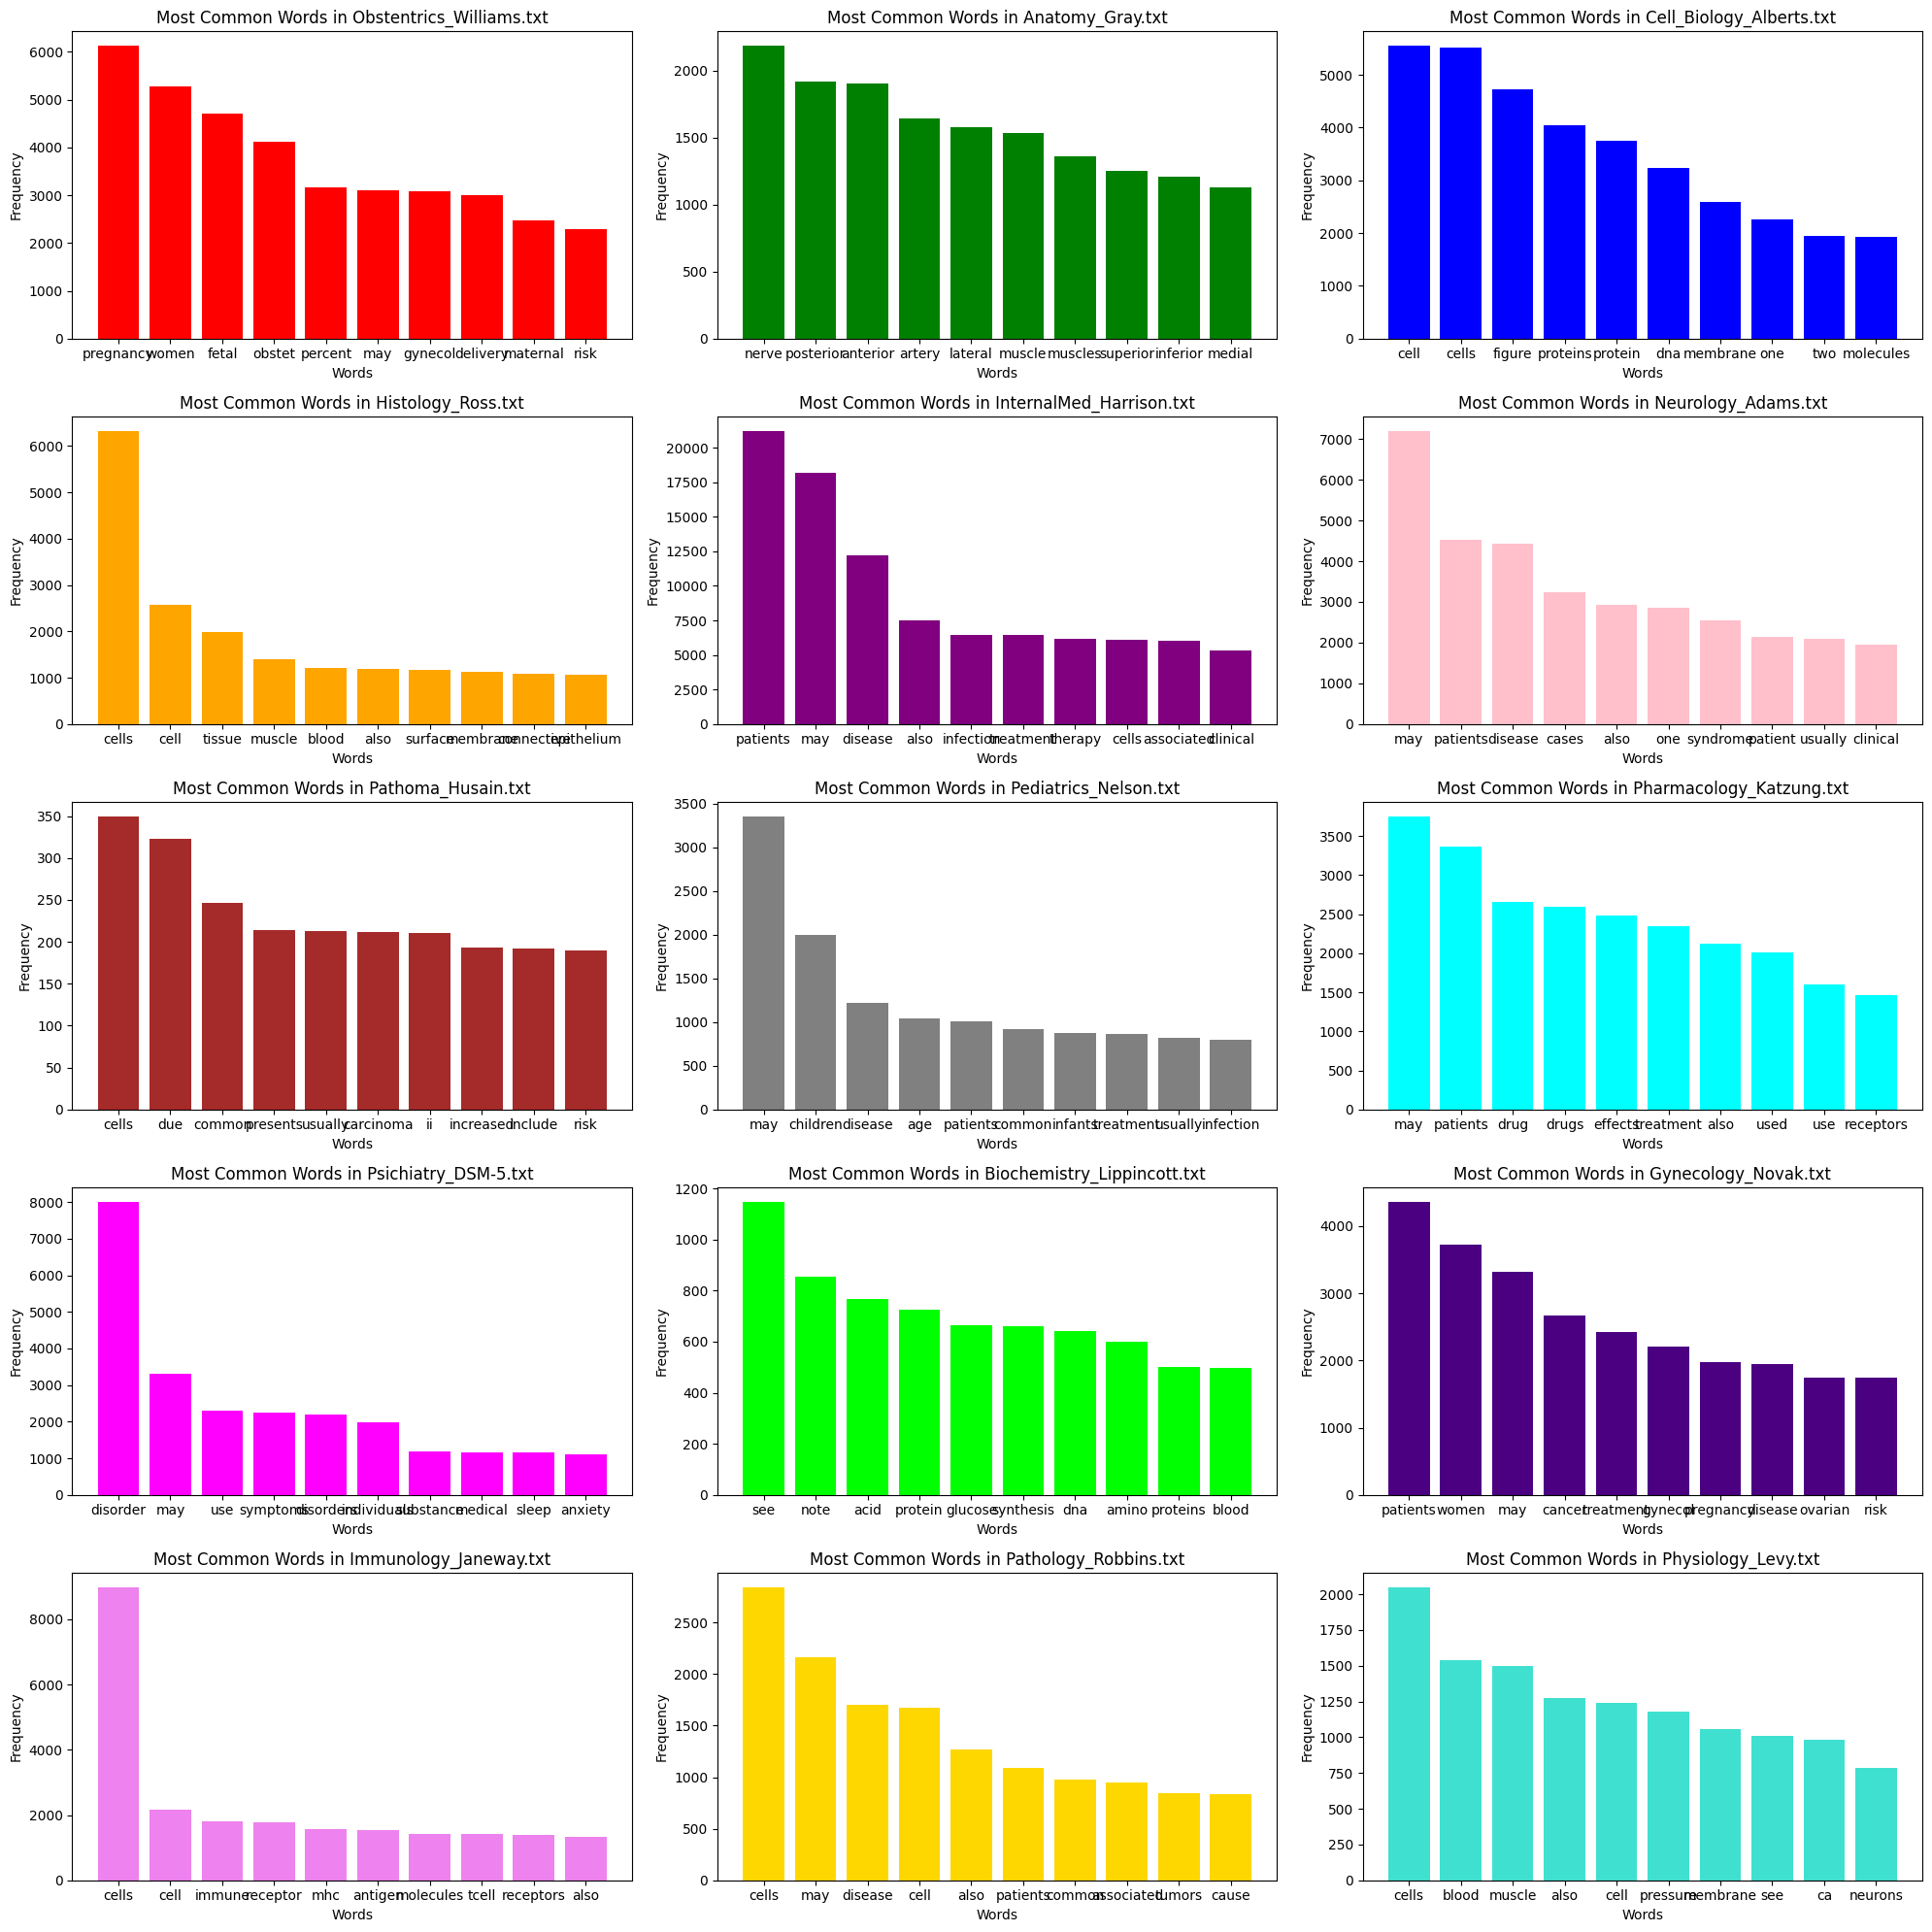

In [ ]:

len(book_paragraphs)

# lowercase all the paragraphs
book_paragraphs_lower = []
for book in book_paragraphs:
    book_paragraphs_lower.append([paragraph.lower() for paragraph in book])

# remove punctuation
import string

book_paragraphs_no_punct = []
for book in book_paragraphs_lower:
    book_paragraphs_no_punct.append([paragraph.translate(str.maketrans('', '', string.punctuation)) for paragraph in book])

# tokenize all the paragraphs
book_paragraphs_tokenized = []

for book in book_paragraphs_no_punct:
    book_paragraphs_tokenized.append([paragraph.split() for paragraph in book])

len(book_paragraphs_tokenized[0][0])

# remove the stopwords
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

book_paragraphs_no_stopwords = []
for book in book_paragraphs_tokenized:
    book_paragraphs_no_stopwords.append([[word for word in paragraph if word not in stop_words] for paragraph in book])

len(book_paragraphs_no_stopwords[0][0])

# remove all the numbers
book_paragraphs_no_numbers = []
for book in book_paragraphs_no_stopwords:
    book_paragraphs_no_numbers.append([[word for word in paragraph if not word.isdigit()] for paragraph in book])

# remove all the tokens with a single letter
book_paragraphs_no_single_letter = []
for book in book_paragraphs_no_numbers:
    book_paragraphs_no_single_letter.append([[word for word in paragraph if len(word) > 1] for paragraph in book])

# remove "fig", "eg", "al"
book_paragraphs_no_fig = []
for book in book_paragraphs_no_single_letter:
    book_paragraphs_no_fig.append([[word for word in paragraph if word not in ["fig", "eg", "al", "et"]] for paragraph in book])

# find the most common words
from collections import Counter

book_words = []

for book in book_paragraphs_no_fig:
    book_words.append([word for paragraph in book for word in paragraph])

book_words_count = []

for book in book_words:
    book_words_count.append(Counter(book))

# plot the most common words for each book
import matplotlib.pyplot as plt

colors = [
    'red', 'green', 'blue', 'orange', 'purple',
    'pink', 'brown', 'gray', 'cyan', 'magenta',
    'lime', 'indigo', 'violet', 'gold', 'turquoise'
]

fig, axs = plt.subplots(5, 3, figsize=(20, 20))

for i, book in enumerate(book_words_count):
    axs[i // 3, i % 3].bar([word[0] for word in book.most_common(10)], [word[1] for word in book.most_common(10)], color=colors[i])
    axs[i // 3, i % 3].set_xlabel('Words')
    axs[i // 3, i % 3].set_ylabel('Frequency')
    axs[i // 3, i % 3].set_title(f'Most Common Words in {other_books[i]}')

plt.tight_layout()
plt.show()

The most frequent words are actually very much related to the area the book is about

**Compute embeddings**

In [ ]:
# Define hnswlib index path
embeddings_cache_path = './indexes/books_embeddings_cache.pkl'

# Load cache if available
if os.path.exists(embeddings_cache_path):
    print('Loading embeddings cache')
    with open(embeddings_cache_path, 'rb') as f:
        corpus_embeddings = pickle.load(f)
# Else compute embeddings
else:
    print('Computing embeddings')
    corpus_embeddings = semb_model.encode(dataset_list, convert_to_tensor=True, show_progress_bar=True)
    # Save the index to a file for future loading
    print(f'Saving index to: \'{embeddings_cache_path}\'')
    with open(embeddings_cache_path, 'wb') as f:
        pickle.dump(corpus_embeddings, f)

Loading embeddings cache


Create index

In [ ]:
# Create empthy index
index = hnswlib.Index(space='cosine', dim=384)

# Define hnswlib index path
index_path = './indexes/books_hnswlib.index'

# Load index if available
if os.path.exists(index_path):
    print('Loading index...')
    index.load_index(index_path)
# Else index data collection
else:
    # Initialise the index
    print('Started creating HNSWLIB index')
    index.init_index(max_elements=corpus_embeddings.size(0), ef_construction=400, M=64)
    #  Compute the HNSWLIB index (it may take a while)
    index.add_items(corpus_embeddings.cpu(), list(range(len(corpus_embeddings))))
    # Save the index to a file for future loading
    print(f'Saving index to: {index_path}')
    index.save_index(index_path)

Started creating HNSWLIB index
Saving index to: ./indexes/books_hnswlib.index


We evaluate the performance of the model, again we choose accuracy as metric

#### Results

In [ ]:
results=[]
for question in prepared_questions:
    results.append(qa_pipeline_book(question))

pprint.pprint(find_accuracy(scoring, results))

34.42622950819672


###Comments
Our first real improvement, but still very far from our goal (>60% accuracy). Are our datasets the problem, or is the task asking too much for the model we are currently using? Lets see one example of question.



In [ ]:
pprint.pprint(USMLE_dataset[0])
pprint.pprint(scoring[0])

{'no': 1,
 'options': {'A': '105-155',
             'B': '120-140',
             'C': '125-135',
             'D': '128-132',
             'E': '129-131'},
 'question': 'Serum LDL-cholesterol concentrations are measured in blood '
             'samples collected from 25 healthy volunteers. The data follow a '
             'normal distribution. The mean and standard deviation for this '
             'group are 130 mg/dL and 25 mg/dL, respectively. The standard '
             'error of the mean is 5.0. With a 95% confidence level, the true '
             'mean for the population from which this sample was drawn falls '
             'within which of the following ranges (in mg/dL)?'}
'B'


Uhm, the questions are really verbose. Also, it seems that answering correctly requires (in some cases) calculations from data given by the question.

Before giving up, let's try a different approach for the problem.

## Fine-tuning

Now we want to understand if fine-tuning a pre-trained model can be useful or not.

We'll use the similarity score to choose among the optioons for each question.

Here we define some functions we'll use.

In [ ]:
# Load pre-trained model for generating sentence embeddings
model_sim = SentenceTransformer('paraphrase-MiniLM-L6-v2')

In [ ]:
def compute_similarity(embeddings1, embeddings2):

    # Calculate cosine similarity between the embeddings
    similarity = util.pytorch_cos_sim(embeddings1, embeddings2)
    return similarity.item()

In [ ]:
index_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4:'E', 5:'F', 6:'G', 7:'H'}

def select_best_sim(gen_answer, options, model_sim):
  #for q in USMLE_dataset:
  embedded_gen = model_sim.encode(gen_answer, convert_to_tensor=True)
  similarities = []
  for o in options:
    embedded_opt = model_sim.encode(o, convert_to_tensor=True)
    similarities.append(compute_similarity(embedded_gen, embedded_opt))
  best_option_index = similarities.index(max(similarities))
  return index_to_letter[best_option_index]

### Pre-trained model

Here we use a model which has not been fine-tuned

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_source = "google/flan-t5-base"
model_nft = T5ForConditionalGeneration.from_pretrained(model_source, device_map="cuda").to(device)
tokenizer_ft = T5Tokenizer.from_pretrained("google/flan-t5-base")

In [ ]:
generated_answers = []

for text in prepared_questions:

  # Tokenize the input text
  inputs = tokenizer_ft.encode("please answer the question:" + text, return_tensors="pt", max_length=512, truncation=False).to(device)
  # Perform inference
  outputs = model_nft.generate(inputs, max_length=512, early_stopping=False, repetition_penalty=2.0,  # Increase penalty to reduce repetition
                                  temperature=0.7,  # Control randomness
                                  top_k=50,  # Consider top 50 tokens
                                  top_p=0.9)

  # Decode the generated output
  generated_text = tokenizer_ft.decode(outputs[0], skip_special_tokens=True)

  generated_answers.append(generated_text)

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


In [ ]:
selected_letters = []

for i in range(len(generated_answers)):
  selected_letters.append(select_best_sim(generated_answers[i], USMLE_dataset[i]['options'], model_sim))

find_accuracy(selected_letters, scoring)

25.40983606557377

### Fine-tuned model

Here we use the model after fine-tuning.

We fine-tuned the 'flan-t5 base' model with our flashcards.
The code is available in the folder "Fine-tuning".

Here we load the fine-tuned model

(note: the finetuned model is available in the linked drive folder at the start of the notebook)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ft = T5ForConditionalGeneration.from_pretrained('checkpoints/fine_tuned').to(device)
tokenizer_ft = T5Tokenizer.from_pretrained("google/flan-t5-base")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Prepare your input data

In [ ]:
generated_answers = []

for text in prepared_questions:

  # Tokenize the input text
  inputs = tokenizer_ft.encode("please answer the question:" + text, return_tensors="pt", max_length=512, truncation=False).to(device)
  # Perform inference
  outputs = model_ft.generate(inputs, max_length=512, early_stopping=False, repetition_penalty=2.0,  # Increase penalty to reduce repetition
                                  temperature=0.7,  # Control randomness
                                  top_k=50,  # Consider top 50 tokens
                                  top_p=0.9)

  # Decode the generated output
  generated_text = tokenizer_ft.decode(outputs[0], skip_special_tokens=True)

  generated_answers.append(generated_text)

Evaluation

In [ ]:
selected_letters = []

for i in range(len(generated_answers)):
  selected_letters.append(select_best_sim(generated_answers[i], USMLE_dataset[i]['options'], model_sim))

find_accuracy(selected_letters, scoring)

20.21857923497268

### Comments
For resource constraints we had to use a very small model (only 330M parameters!😭).

Additionally, the finetuning was performed with a question-answer structure which was very different from the test question/answer strucure, hence the lowering of performances _after_ finetuning.

## Testing with an LLM

### Introduction
Now we want to test a complex model (3.8B parameters!🤩) with the same questions used in our pipeline, to see if the complexity of the model affects the results.

For this section we used the model available here:
- https://huggingface.co/microsoft/Phi-3-mini-4k-instruct

In [ ]:
model_llm = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True,
)
tokenizer_llm = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")
pipe = pipeline(
    "text-generation",
    model=model_llm,
    tokenizer=tokenizer_llm,
)
generation_args = {
    "max_new_tokens": 600,
    "return_full_text": False,
    "temperature": 0.3,
    "do_sample": True,
}

#### Utils
the model seem to return the answer as "X: some text", with X being the selected option. We made a function to extract only that selected option.



In [8]:
def get_answer(ans_list):
  answers=[]
  for string in ans_list:
    answers.append(string[0])
  return answers
#given 2 lists, find the accuracy, where points are "given" only with an exact match
def find_accuracy(generated, ground_truth):
  matches = sum(1 for x, y in zip(ground_truth, generated) if x == y)
  accuracy = matches / len(ground_truth) * 100

  # Print the resulting accuracy
  return accuracy

### ...with a simple prompt

We give the model the question+options, and we ask him to answer by selecting an option

In [9]:
system_prompt = "You are a medicine student taking a multiple choice quiz."
user_prompt = "Answer this question only with the selected option: "

In [13]:
def generate_ans(full_string):
  user_request = user_prompt + full_string
  messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_request},
  ]
  output = pipe(messages, **generation_args)
  #print(output[0]['generated_text'])

  return output[0]['generated_text']

In [ ]:
selected_options = []

for question in prepared_questions:

  selected = generate_ans(question).strip()
  selected_options.append(selected)

print(find_accuracy(get_answer(selected_options), scoring))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


60.38251366120219


### ...with a 'step-by-step' prompt
Prompting the model to reason the answer, then perform an additional layer in order to extract the answer might yield a better result. Let's try it!

In [ ]:
system_prompt = "You are a medicine student taking a multiple choice quiz."
user_prompt="Answer this question, explaining step by step the reasoning behind your answer: "

In [ ]:
selected_options = []

for question in prepared_questions:

  selected = generate_ans(question).strip()
  selected_options.append(selected)

In [ ]:
index=random.randint(1, len(selected_options))# print a random response
pprint.pprint(prepared_questions[index])
pprint.pprint(selected_options[index])

('A 10-year-old boy is brought to the emergency department in the middle of '
 'summer because of fever, headache, and photophobia. Several of his camp '
 'mates have had a similar illness. Physical examination shows mild nuchal '
 'rigidity. A lumbar puncture is performed. Laboratory studies show: Serum '
 'glucose 90 mg/dL Cerebrospinal fluid Pressure, opening 50 mm H2O Glucose 65 '
 'mg/dL Total protein 70 mg/dL Leukocyte count 43/mm3 (95% lymphocytes) Which '
 'of the following infectious agents is the most likely cause of these '
 'findings? A: Adenovirus, B: Enterovirus, C: Herpes simplex virus, D: '
 'Neisseria meningitidis, E: Streptococcus pneumoniae')
('The most likely cause of these findings is B: Enterovirus.\n'
 '\n'
 'Here is the step-by-step reasoning behind this answer:\n'
 '\n'
 "1. The patient's symptoms: fever, headache, photophobia, and nuchal rigidity "
 'are all common symptoms of meningitis, an inflammation of the meninges, the '
 'membranes that surround the bra

In [ ]:
file_path = 'llm_verbose_generation.json'

# Save the list as a JSON file
with open(file_path, 'w') as json_file:
    json.dump(selected_options, json_file)

Now we give him the answer previously generated responses and ask it to select only the corresponding option.

In [12]:
file_path = 'llm_verbose_generation.json'

with open(file_path, 'r') as json_file:
    verbose_ans = json.load(json_file)

In [15]:
system_prompt = "You are a nice chatbot, helping a medicine student in a multiple-choice quiz."
user_prompt = "Given my step-by-step answer, select the letter corresponding to the chosen option: "

In [ ]:
file_path = 'llm_verbose_generation.json' #due to resource constraints, only the first 157 questions were answered

with open(file_path, 'r') as json_file:
    verbose_ans = json.load(json_file)

letters = []

for a in verbose_ans:
  letter = generate_ans(a).strip()
  letters.append(letter)

In [21]:
print(find_accuracy(get_answer(letters), scoring[:157]))

61.78343949044586


## Comments
As expected, the bigger model performed much better than the other smaller ones (🥸) with significative improvement in the accuracy.

### ...with 'paraphrase evaluation'

Our thirst(🥵) for knowledge made us explore other possibilities for the dataset provided.

Now we use it as a test dataset, to check the model generated answer and the "true" answer by performing a similarity check.

The range is from 0 to 1. A decent result would be above 0.5 with it getting better the closer to 1 it gets.

In [ ]:
system_prompt = "You are a medicine student taking a quiz."
user_prompt = "Answer this question: "

# Load pre-trained model for generating sentence embeddings
model_sim = SentenceTransformer('paraphrase-MiniLM-L6-v2')
def compute_similarity(embeddings1, embeddings2):

    # Calculate cosine similarity between the embeddings
    similarity = util.pytorch_cos_sim(embeddings1, embeddings2)
    return similarity.item()

In [ ]:
# We ask only around 100 questions to the model, since it would take to long to ask all the questions present in the dataset
generated_ans=[]
embedded_generated=[]
embedded_original=[]
scores=[]
for i in range (100):

  print(i)
  generated_ans.append(generate_ans(combined_questions['original'][i]).strip())
  embedded_generated.append(model_sim.encode(generated_ans[i], convert_to_tensor=True))
  embedded_original.append(model_sim.encode(combined_answers['original'][i], convert_to_tensor=True))
  scores.append(compute_similarity(embedded_generated[i], embedded_original[i]))

print(f'average score: {sum(scores)/len(scores)}')
#due to a print in the for, scroll the output to see the score!🤯


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
average score: 0.7256189468502998


#Conclusions

Using finetuning to make the model learn notions proved unsuccessful, indeed, even counterproductive, if the finetuned model was then tested by submitting multiple-choice questions. RAG gave better results than finetuning, but performance, as we expected, is closely related to the size of the dataset from which retrival is done and to the complexity of the question. The best results were obtained with more complex models, suggesting that the type of question is difficult to process for a smaller model.

The method one uses to test the model has non-indefferent impacts on attested performance, in fact:
- using multiple-response questions is certainly an objective method, but the model is likely to perform very poorly if it is not guided in formulating the answer.
- using functions such as similarity between the generated answer and the correct one, risks giving very low scores, because often the model generates answers that are not wrong, but do not match the desired one

<ipython-input-32-0ee54c7492b4>:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('RdYlGn')  # 'RdYlGn_r' for reverse (Red to Green)


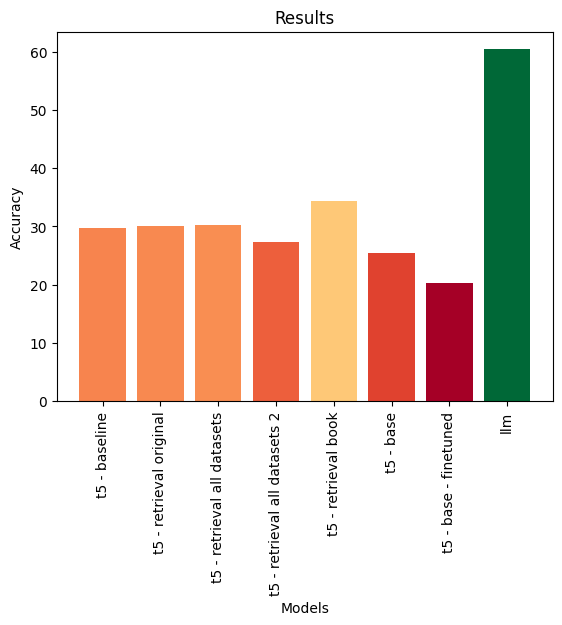

In [32]:
# Plot the values
values=[29.78, 30.05, 30.33, 27.32, 34.43, 25.41, 20.22, 60.38]
# manually inserted from the outputs obtained previously!😶‍🌫️


names = ['t5 - baseline', 't5 - retrieval original', 't5 - retrieval all datasets', 't5 - retrieval all datasets 2', 't5 - retrieval book', 't5 - base', 't5 - base - finetuned', 'llm']

norm = plt.Normalize(min(values), max(values))

# Create a colormap (Green to Red)
cmap = plt.cm.get_cmap('RdYlGn')  # 'RdYlGn_r' for reverse (Red to Green)

# Generate colors based on the values
colors = cmap(norm(values))

# Create the bar plot
plt.bar(names, values, color=colors)

# Set the x-axis labels
plt.xticks( rotation=90)

# Adding titles and labels
plt.title('Results')
plt.xlabel('Models')
plt.ylabel('Accuracy')

# Display the plot
plt.show()

# goodbye

In [ ]:
cowsay.cow('thank you for listening! 😘')

  __________________________
| thank you for listening! 😘 |
                          \
                           \
                             ^__^
                             (oo)\_______
                             (__)\       )\/\
                                 ||----w |
                                 ||     ||


In [ ]:
cowsay.cow("please give us max score 🥹")

  __________________________
| please give us max score 🥹 |
                          \
                           \
                             ^__^
                             (oo)\_______
                             (__)\       )\/\
                                 ||----w |
                                 ||     ||
